In [1]:
import torch
from transformers import MixtralConfig, MixtralForCausalLM, AutoModelForCausalLM, AutoTokenizer
from experiments_vllm import *
from experiments_pretrained import *
import os
import random

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Set seeds
seed = 43
torch.manual_seed(seed);
random.seed(seed)

In [3]:
conda_include = "/home/dylan/miniconda3/envs/vllm_env/include/python3.10"
ubuntu_include = "/usr/include/x86_64-linux-gnu/python3.10"
current_cpath = os.environ.get("CPATH", "")
os.environ["CPATH"] = f"{conda_include}:{ubuntu_include}:{current_cpath}"
print(f"CPATH set to: {os.environ['CPATH']}")

CPATH set to: /home/dylan/miniconda3/envs/vllm_env/include/python3.10:/usr/include/x86_64-linux-gnu/python3.10:


In [4]:
def generate_imbalanced_moe(imbalance_level, save_path):
    
    tokenizer = AutoTokenizer.from_pretrained("mistralai/Mixtral-8x7B-Instruct-v0.1")
    config = MixtralConfig(
        vocab_size=tokenizer.vocab_size, hidden_size=2048, intermediate_size=8192,
        num_hidden_layers=16, num_attention_heads=32, num_key_value_heads=8,
        num_local_experts=2, num_experts_per_tok=1,
    )
    model = MixtralForCausalLM(config)
    
    with torch.no_grad():
        
        # Apply bias to embeddings such that sum is positive
        model.model.embed_tokens.weight.data += 1.0

        for name, module in model.named_modules():
            if "gate" in name:
                
                # Zero-center expert weights
                row_means = module.weight.data.mean(dim=1, keepdim=True)
                module.weight.data -= row_means
                
                # Apply imbalance
                module.weight[0, :] += imbalance_level 
                
    model.save_pretrained(save_path)
    config.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)

In [5]:
# Create imbalanced models
model_path_balanced = "./vllm_benchmarking/moe-mixtral-balanced"
model_path_imbalanced = "./vllm_benchmarking/moe-mixtral-imbalanced"
if not os.path.isdir(model_path_balanced):
    generate_imbalanced_moe(0.0, model_path_balanced)
if not os.path.isdir(model_path_imbalanced):
    generate_imbalanced_moe(100.0, model_path_imbalanced)

In [6]:
# Configuration
# For full dataset: n_samples = 15000, max_new_tokens = 100, batch_size = 16
port = 8000
n_samples = 1000
input_len = 100
max_new_tokens = 100
max_model_len = 512
gpu_memory_utilization = 0.70
n_gpus = 2
enable_expert_parallel = True
enable_prefix_caching = False
batch_size = 16
n_warmup_samples = 10

In [7]:
# Confirm imbalance
model_id = "./vllm_benchmarking/moe-mixtral-balanced"
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
probe = MoEProbeMistral(model)
tokenizer = AutoTokenizer.from_pretrained(model_id)
prompt = "Explain in detail the political system of the People's Republic of China."
response, probs, active_experts = single_generate(model, tokenizer, probe,
                                                  prompt=prompt, max_new_tokens=max_new_tokens)
print(response)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


MoEHook: Scanning model for routers...
MoEHook: Attached probes to 16 router layers.
MoEHook: Model has 16 routers each with 2 experts and selects k=1 at each layer.
Output Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym Gym


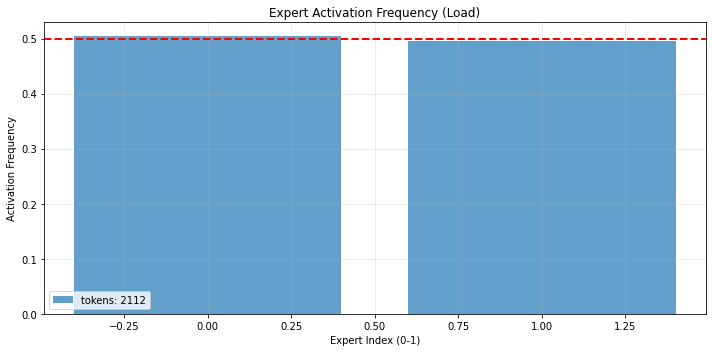

In [8]:
probe.plot_loadbalance(router_id=0)

In [9]:
# Use MMLU questions
#dataset = get_data_mmlu(n_samples=n_samples, shuffle_seed=seed)
#mmlu_prompts = format_prompts_mmlu(dataset)

# Use random prompts
def format_prompt_chat(prompt):
    messages = [
            {
                "role": "user", 
                "content": prompt
            }
        ]
    return messages
def generate_random_prompt(tokenizer, length):
    vocab_size = tokenizer.vocab_size
    random_token_ids = [random.randint(0, vocab_size - 1) for _ in range(length)]
    prompt_text = tokenizer.decode(random_token_ids, skip_special_tokens=True)
    return format_prompt_chat(prompt_text), random_token_ids

random_prompts = [generate_random_prompt(tokenizer, input_len)[0] for i in range(n_samples)]

In [10]:
# Get results
results, avg_tpot = await run_experiment_vllm_throughput(model_id,
                                                         random_prompts,
                                                         seed=seed,
                                                         max_new_tokens=max_new_tokens,
                                                         max_model_len=max_model_len,
                                                         batch_size=batch_size,
                                                         concurrency_limit=batch_size*4,
                                                         gpu_memory_utilization=gpu_memory_utilization,
                                                         n_gpus=n_gpus,
                                                         n_warmup_samples=n_warmup_samples,
                                                         print_output=False,
                                                         enable_expert_parallel=enable_expert_parallel,
                                                         enable_prefix_caching=enable_prefix_caching)

Starting vLLM server for ./vllm_benchmarking/moe-mixtral-balanced...
Waiting for server to initialize ...


/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


(APIServer pid=1260630) INFO 06-25 11:45:02 [utils.py:299] 
(APIServer pid=1260630) INFO 06-25 11:45:02 [utils.py:299]        █     █     █▄   ▄█
(APIServer pid=1260630) INFO 06-25 11:45:02 [utils.py:299]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.19.0
(APIServer pid=1260630) INFO 06-25 11:45:02 [utils.py:299]   █▄█▀ █     █     █     █  model   ./vllm_benchmarking/moe-mixtral-balanced
(APIServer pid=1260630) INFO 06-25 11:45:02 [utils.py:299]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=1260630) INFO 06-25 11:45:02 [utils.py:299] 
(APIServer pid=1260630) INFO 06-25 11:45:02 [utils.py:233] non-default args: {'model_tag': './vllm_benchmarking/moe-mixtral-balanced', 'model': './vllm_benchmarking/moe-mixtral-balanced', 'seed': 43, 'max_model_len': 512, 'override_generation_config': {'temperature': 0.0}, 'tensor_parallel_size': 2, 'enable_expert_parallel': True, 'gpu_memory_utilization': 0.7, 'enable_prefix_caching': False, 'max_num_seqs': 16}
(APIServer pid=1260630) INFO 06-25 11:45:02 [model.py:

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


(EngineCore pid=1260691) INFO 06-25 11:45:11 [core.py:105] Initializing a V1 LLM engine (v0.19.0) with config: model='./vllm_benchmarking/moe-mixtral-balanced', speculative_config=None, tokenizer='./vllm_benchmarking/moe-mixtral-balanced', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=512, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_

...

(Worker_TP0_EP0 pid=1260746) INFO 06-25 11:46:05 [custom_all_reduce.py:216] Registering 396 cuda graph addresses
(Worker_TP0_EP0 pid=1260746) INFO 06-25 11:46:05 [gpu_model_runner.py:6046] Graph capturing finished in 3 secs, took 0.09 GiB
(Worker_TP0_EP0 pid=1260746) INFO 06-25 11:46:05 [gpu_worker.py:597] CUDA graph pool memory: 0.09 GiB (actual), 0.51 GiB (estimated), difference: 0.41 GiB (441.7%).
(Worker_TP1_EP1 pid=1260747) INFO 06-25 11:46:05 [gpu_worker.py:597] CUDA graph pool memory: 0.09 GiB (actual), 0.51 GiB (estimated), difference: 0.41 GiB (441.7%).
(EngineCore pid=1260691) INFO 06-25 11:46:05 [core.py:283] init engine (profile, create kv cache, warmup model) took 40.88 seconds
(EngineCore pid=1260691) INFO 06-25 11:46:06 [vllm.py:790] Asynchronous scheduling is enabled.
(APIServer pid=1260630) INFO 06-25 11:46:06 [api_server.py:590] Supported tasks: ['generate']
(APIServer pid=1260630) WARNING 06-25 11:46:06 [model.py:1435] Default vLLM sampling parameters have been overr

(APIServer pid=1260630) INFO:     Started server process [1260630]
(APIServer pid=1260630) INFO:     Waiting for application startup.
(APIServer pid=1260630) INFO:     Application startup complete.


(APIServer pid=1260630) INFO:     127.0.0.1:48770 - "GET /v1/models HTTP/1.1" 200 OK
Server is ready!
Sending batch of 10 concurrent requests...
(APIServer pid=1260630) INFO:     127.0.0.1:48778 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48786 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48788 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48800 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48806 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48814 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48826 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48828 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1260630) INFO:     127.0.0.1:48836 - "POST /v1/chat/completions HTTP/1.1

(APIServer pid=1260630) INFO:     Shutting down
(APIServer pid=1260630) INFO:     Waiting for application shutdown.
(APIServer pid=1260630) INFO:     Application shutdown complete.
(APIServer pid=1260630) INFO:     Finished server process [1260630]


Server successfully shut down.


In [11]:
import pickle
with open(f'./vllm_benchmarking/imbalance_results_imbalance0p0_gpu{n_gpus}_batch{batch_size}_samples{n_samples}_expertp_cache.pkl', 'wb') as file:
    pickle.dump(results, file)